# Mobility quantification

In [1]:
%load_ext autoreload
%autoreload 2
%cd D:\netmob25

D:\netmob25


In [3]:
# Load libs
import pandas as pd
import numpy as np
import os
os.environ['USE_PYGEOS'] = '0'
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import h3.api.numpy_int as h3
from lib import helpers as helpers
from collections import Counter

## 1. Load trip records and process

In [34]:
df = pd.read_parquet(f'dbs/data_p/stays_extraction_all.parquet')
df.head()

,trip_id,start_time,end_time,duration,weight_day,purpose_o,purpose_d,day_type,dow,start_lat,start_lon,end_lat,end_lon,ID
0,2023-03-15_1,2023-03-15 16:40:01,2023-03-15 16:54:59,15.0,235.905683,DEPART_HOME,OTHER,Normal,wednesday,48.865031,2.139098,48.866024,2.144520,10_2978
1,2023-03-15_2,2023-03-15 17:00:00,2023-03-15 17:10:59,11.0,235.905683,OTHER,RETURN_HOME,Normal,wednesday,48.865527,2.141809,48.866651,2.141281,10_2978
2,2023-03-15_3,2023-03-15 17:36:00,2023-03-15 17:51:00,15.0,235.905683,DEPART_HOME,ACCOM,Normal,wednesday,48.866964,2.139661,48.819422,2.126685,10_2978
3,2023-03-15_4,2023-03-15 18:12:00,2023-03-15 18:26:00,14.0,235.905683,ACCOM,RETURN_HOME,Normal,wednesday,48.817488,2.126122,48.865031,2.139098,10_2978
4,2023-03-16_1,2023-03-16 08:12:00,2023-03-16 08:17:00,5.0,218.345882,DEPART_HOME,OTHER,Normal,thursday,48.866651,2.141281,48.866024,2.144520,10_2978


In [5]:
df.columns

Index(['trip_id', 'start_time', 'end_time', 'duration', 'weight_day',
       'purpose_o', 'purpose_d', 'day_type', 'dow', 'start_lat', 'start_lon',
       'end_lat', 'end_lon', 'ID'],
      dtype='object')

In [6]:
for var in ['purpose_o', 'purpose_d', 'day_type']:
    print(df[var].unique())

['DEPART_HOME' 'OTHER' 'ACCOM' 'PURCHASE' 'WORK' 'BUSINESS' 'LEISURE'
 'HEALTH' 'STUDIES']
['OTHER' 'RETURN_HOME' 'ACCOM' 'PURCHASE' 'WORK' 'LEISURE' 'BUSINESS'
 'HEALTH' 'STUDIES']
['Normal' 'School holiday' 'Public holiday' 'Bridge day' 'Strike']


In [35]:
# Ensure datetimes
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time']   = pd.to_datetime(df['end_time'])

# Extract day from trip_id (YYYY-MM-DD_Number)
df['date'] = df['trip_id'].str.split('_').str[0]

# Sort within person-day
df = df.sort_values(['ID', 'date', 'start_time'])

# Flag first row per person-day
is_first = df.groupby(['ID', 'date']).cumcount() == 0

# 1) Preceding activity: previous destination; for the first trip that departs home, set to DEPART_HOME
df['preceding_activity'] = df['purpose_o'].apply(lambda x: x if x != 'DEPART_HOME' else 'HOME')

# 2) Activity duration (minutes): default is current start - previous end;
#    for the first trip that departs home, use midnight of that date as the "previous end"
prev_end = df.groupby(['ID', 'date'])['end_time'].shift(1)
midnight = df['start_time'].dt.normalize()  # 00:00 of that calendar day

prev_end_adjusted = prev_end.where(~(is_first & (df['purpose_o'] == 'DEPART_HOME')), midnight)

dt = (df['start_time'] - prev_end_adjusted).dt.total_seconds() / 60.0
df['activity_duration_min'] = np.clip(dt.fillna(0), 0, None)

In [36]:
df['purpose_d'] = df['purpose_d'].apply(lambda x: x if 'HOME' not in x else 'HOME')
df['purpose_o'] = df['purpose_o'].apply(lambda x: x if 'HOME' not in x else 'HOME')

In [9]:
df.head()

,trip_id,start_time,end_time,duration,weight_day,purpose_o,purpose_d,day_type,dow,start_lat,start_lon,end_lat,end_lon,ID,date,preceding_activity,activity_duration_min
0,2023-03-15_1,2023-03-15 16:40:01,2023-03-15 16:54:59,15.0,235.905683,HOME,OTHER,Normal,wednesday,48.865031,2.139098,48.866024,2.144520,10_2978,2023-03-15,HOME,1000.016667
1,2023-03-15_2,2023-03-15 17:00:00,2023-03-15 17:10:59,11.0,235.905683,OTHER,HOME,Normal,wednesday,48.865527,2.141809,48.866651,2.141281,10_2978,2023-03-15,OTHER,5.016667
2,2023-03-15_3,2023-03-15 17:36:00,2023-03-15 17:51:00,15.0,235.905683,HOME,ACCOM,Normal,wednesday,48.866964,2.139661,48.819422,2.126685,10_2978,2023-03-15,HOME,25.016667
3,2023-03-15_4,2023-03-15 18:12:00,2023-03-15 18:26:00,14.0,235.905683,ACCOM,HOME,Normal,wednesday,48.817488,2.126122,48.865031,2.139098,10_2978,2023-03-15,ACCOM,21.000000
4,2023-03-16_1,2023-03-16 08:12:00,2023-03-16 08:17:00,5.0,218.345882,HOME,OTHER,Normal,thursday,48.866651,2.141281,48.866024,2.144520,10_2978,2023-03-16,HOME,492.000000


Consider anchor locations (>= 30 min)

In [37]:
df_anchor = df[df['activity_duration_min'] >= 30].copy()
df_anchor['preceding_activity'].value_counts()

preceding_activity
HOME        24023
WORK         9034
LEISURE      5284
PURCHASE     4087
OTHER        3990
BUSINESS     2289
STUDIES      1300
HEALTH       1095
ACCOM         999
Name: count, dtype: int64

## 2. Trip chaining calculation

In [ ]:
# df = df[df['dow'].isin(['wednesday', 'thursday', 'friday', 'monday', 'tuesday'])]

In [38]:
# Define categories
third_places_set = {'LEISURE'} # {'PURCHASE', 'LEISURE', 'HEALTH', 'OTHER', 'BUSINESS', 'ACCOM'}
work_study_set = {'WORK', 'STUDIES'}
# home_set = {'DEPART_HOME', 'RETURN_HOME'}
THRESH_MIN = 30
CORE = {'HOME', 'WORK', 'STUDIES'}

In [11]:
df['date'] = df['trip_id'].str.split('_').str[0]
df = df.sort_values(['ID', 'date', 'start_time'])

In [39]:
# Consider 1) for now
# two types of chaning: # 1) CORE–CORE (different endpoints), and activities in between are nonCORE
# 2) CORE/nonCORE–nonCORE (exactly one endpoint is CORE, and nonCORE are those have activity duration >= THRESH_MIN)
def summarize_day(group):
    durations = group['duration'].tolist()
    activity_durations = group['activity_duration_min'].tolist()
    # Build the activity sequence: first origin activity of the day + all destinations
    acts = [group['purpose_o'].tolist()[0]] + group['purpose_d'].tolist()

    # Add a trailing "last activity" anchor if there's unused time >= threshold
    last_act = 1 if max(0, 24 * 60 - group['activity_duration_min'].sum()) >= THRESH_MIN else 0

    # Anchor sequence aligned with 'acts'
    anchors = (group['activity_duration_min'] >= THRESH_MIN).astype(int).tolist() + [last_act]

    # Force CORE activities to be anchors = 1
    anchors = [1 if act in CORE else 0 for _, act in enumerate(acts)]
    # anchors = [1 if act in CORE else anchors[i] for i, act in enumerate(acts)]
    #print(f"Anchors: {anchors}", "sequence:", acts)
    # indices of anchored activities
    idx_anchor = [i for i, a in enumerate(anchors) if a == 1]

    freq_A = 0  # CORE–CORE, different endpoints
    freq_B = 0  # CORE–nonCORE (exactly one CORE), different by definition
    xs_A = 0    # total non-CORE in-betweens for A
    xs_B = 0    # total non-CORE in-betweens for B

    for i, j in zip(idx_anchor, idx_anchor[1:]):
        #print(i, j)
        # Require different anchor locations at endpoints
        if acts[i] == acts[j]:
            continue

        # In-between activities (exclusive of endpoints)
        between = acts[i+1:j]
        noncore_between = [a for a in between if a not in CORE]

        # Require at least one non-CORE Xs between endpoints
        if len(noncore_between) < 1:
            continue

        left_core  = acts[i] in CORE
        right_core = acts[j] in CORE

        cond_A = left_core and right_core
        cond_B = (left_core ^ right_core)  # exactly one endpoint is CORE

        if cond_A:
            freq_A += 1
            xs_A += len(noncore_between)
        elif cond_B:
            freq_B += 1
            xs_B += len(noncore_between)

    presence = int((freq_A + freq_B) > 0)
    
    # --- 4. Total travel time ---
    total_travel_time = sum(durations)

    # --- 5. Activity times ---
    activity_time_third = 0
    activity_time_work_study = 0
    for act, dur in zip(acts, activity_durations):
        if act in third_places_set:
            activity_time_third += dur
        elif act in work_study_set:
            activity_time_work_study += dur
    return pd.Series({
        'trip_chaining_presence': presence,
        'freq_hws': freq_A,        # CORE–CORE (different endpoints)
        'freq_hwsx': freq_B,       # CORE–nonCORE
        'xs_total_hws': xs_A,      # total non-CORE Xs for CORE–CORE
        'xs_total_hwsx': xs_B,      # total non-CORE Xs for CORE–nonCORE
        'total_travel_time': total_travel_time,
        'activity_time_third': activity_time_third,
        'activity_time_work_study': activity_time_work_study,
        'activity_time_home': 24*60 - total_travel_time - activity_time_third - activity_time_work_study
    })

In [16]:
example = 3
for _, g in df.groupby(['ID', 'date']):
    summarize_day(g)
    example -= 1
    if example < 0:
        break

In [40]:
tqdm.pandas(desc='Summarizing days')
results = (
    df.groupby(['ID', 'date'], sort=False)
      .progress_apply(summarize_day)
      .reset_index()
)

Summarizing days: 100%|█████████▉| 18646/18736 [00:08<00:00, 2451.29it/s]c:\Users\yuanlia\AppData\Local\miniconda3\envs\labstack\Lib\site-packages\tqdm\std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
Summarizing days: 100%|██████████| 18736/18736 [00:08<00:00, 2138.73it/s]


In [41]:
results.head()

,ID,date,trip_chaining_presence,freq_hws,freq_hwsx,xs_total_hws,xs_total_hwsx,total_travel_time,activity_time_third,activity_time_work_study,activity_time_home
0,10_2978,2023-03-15,0.0,0.0,0.0,0.0,0.0,55.0,0.0,0.000000,1385.000000
1,10_2978,2023-03-16,0.0,0.0,0.0,0.0,0.0,97.0,0.0,0.000000,1343.000000
2,10_2978,2023-03-17,1.0,1.0,0.0,1.0,0.0,271.0,0.0,482.016667,686.983333
3,10_2980,2023-03-13,0.0,0.0,0.0,0.0,0.0,46.0,0.0,707.533333,686.466667
4,10_2980,2023-03-14,0.0,0.0,0.0,0.0,0.0,69.0,0.0,562.250000,808.750000


In [42]:
results['trip_chaining_presence'].value_counts()

trip_chaining_presence
0.0    15173
1.0     3563
Name: count, dtype: int64

In [43]:
results.loc[results['trip_chaining_presence'] == 1, 'ID'].nunique() / results['ID'].nunique()

0.5729355033152501

## 3. Leisure activity participation
### 3.1 Diversity of third-place activities

In [44]:
CORE = {'DEPART_HOME', 'WORK', 'STUDIES'}
THIRD = {'LEISURE'}
def third_place_entropy_mm(group):
    acts = [group['purpose_o'].tolist()[0]] + group['purpose_d'].tolist()
    
    # Filter third place activities only
    third_places = [x for x in acts if x in THIRD]
    n_visits = len(third_places)

    if n_visits == 0:
        return pd.Series({
            'entropy_naive': np.nan,
            'entropy_mm': np.nan,
            'gini_simpson': np.nan,
            'hill_q1': np.nan,
            'n_visits': 0
        })

    # --- 2) All coordinates (start + end) ---
    all_coords = (
        list(zip(group["start_lat"], group["start_lon"])) +
        list(zip(group["end_lat"],   group["end_lon"]))
    )
    all_coords = [(lat, lon) for lat, lon in all_coords
                  if pd.notna(lat) and pd.notna(lon)]

    # --- 3) Convert to H3 resolution 10 ---
    all_h3_r10 = [h3.latlng_to_cell(lat, lon, res=10) for lat, lon in all_coords]
    all_h3_r10 = [h for h in all_h3_r10 if pd.notna(h)]

    # --- 4) Frequency counts ---
    counts = np.array(list(Counter(all_h3_r10).values()), dtype=float)
    n = counts.sum()
    K = len(counts)
    
    # --- 5) Proportions ---
    p = counts / n

    # --- 6) Shannon entropy (naive) ---
    H_naive = -np.sum(p * np.log(p))

    # --- 7) Miller–Madow correction ---
    H_mm = H_naive + (K - 1) / (2 * n)

    # --- 8) Gini–Simpson index ---
    gini_simpson = 1 - np.sum(p ** 2)

    # --- 9) Hill number (q=1) ---
    hill_q1 = np.exp(H_naive)

    return pd.Series({
        'entropy_naive': H_naive,
        'entropy_mm': H_mm,
        'gini_simpson': gini_simpson,
        'hill_q1': hill_q1,
        'n_visits': n
    })

df_ind = df.groupby('ID').apply(third_place_entropy_mm).reset_index()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_18812\2861871492.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ind = df.groupby('ID').apply(third_place_entropy_mm).reset_index()


In [45]:
df_ind.head()

,ID,entropy_naive,entropy_mm,gini_simpson,hill_q1,n_visits
0,10_2978,NaN,NaN,NaN,NaN,0.0
1,10_2980,2.810392,3.089804,0.927336,16.616434,34.0
2,10_2981,2.638284,2.904950,0.911111,13.989175,30.0
3,10_2982,3.166905,3.424481,0.932507,23.733908,66.0
4,10_2984,3.033417,3.304250,0.936632,20.768075,48.0


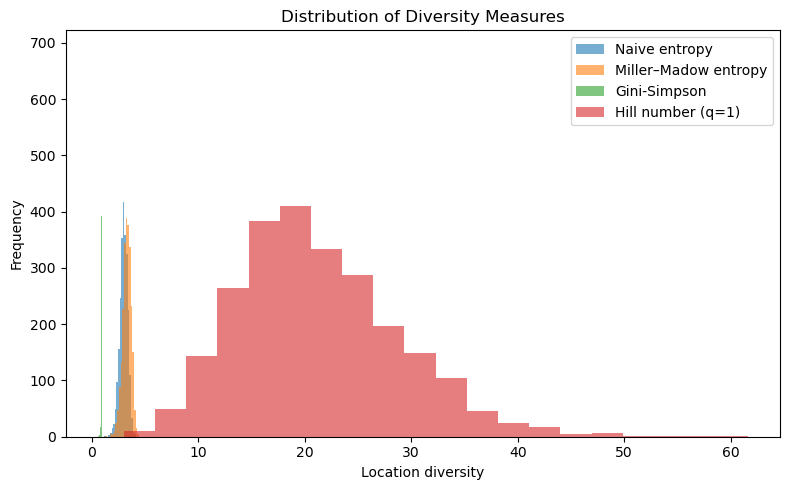

In [46]:
plt.figure(figsize=(8, 5))

plt.hist(df_ind['entropy_naive'].dropna(), bins=20, alpha=0.6, label='Naive entropy')
plt.hist(df_ind['entropy_mm'].dropna(), bins=20, alpha=0.6, label='Miller–Madow entropy')
plt.hist(df_ind['gini_simpson'].dropna(), bins=20, alpha=0.6, label='Gini-Simpson')
plt.hist(df_ind['hill_q1'].dropna(), bins=20, alpha=0.6, label='Hill number (q=1)')

plt.xlabel('Location diversity')
plt.ylabel('Frequency')
plt.title('Distribution of Diversity Measures')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Mobility efficiency data

In [47]:
results = pd.merge(results, df_ind, on='ID', how='left')
results.head()

,ID,date,trip_chaining_presence,freq_hws,freq_hwsx,xs_total_hws,xs_total_hwsx,total_travel_time,activity_time_third,activity_time_work_study,activity_time_home,entropy_naive,entropy_mm,gini_simpson,hill_q1,n_visits
0,10_2978,2023-03-15,0.0,0.0,0.0,0.0,0.0,55.0,0.0,0.000000,1385.000000,NaN,NaN,NaN,NaN,0.0
1,10_2978,2023-03-16,0.0,0.0,0.0,0.0,0.0,97.0,0.0,0.000000,1343.000000,NaN,NaN,NaN,NaN,0.0
2,10_2978,2023-03-17,1.0,1.0,0.0,1.0,0.0,271.0,0.0,482.016667,686.983333,NaN,NaN,NaN,NaN,0.0
3,10_2980,2023-03-13,0.0,0.0,0.0,0.0,0.0,46.0,0.0,707.533333,686.466667,2.810392,3.089804,0.927336,16.616434,34.0
4,10_2980,2023-03-14,0.0,0.0,0.0,0.0,0.0,69.0,0.0,562.250000,808.750000,2.810392,3.089804,0.927336,16.616434,34.0


In [48]:
results.columns

Index(['ID', 'date', 'trip_chaining_presence', 'freq_hws', 'freq_hwsx',
       'xs_total_hws', 'xs_total_hwsx', 'total_travel_time',
       'activity_time_third', 'activity_time_work_study', 'activity_time_home',
       'entropy_naive', 'entropy_mm', 'gini_simpson', 'hill_q1', 'n_visits'],
      dtype='object')

In [49]:
results['activity_nh_ratio'] = (results['activity_time_third'] + results['activity_time_work_study']) / results['total_travel_time']

In [51]:
results.groupby('trip_chaining_presence').agg({
    'activity_nh_ratio': 'mean',
    'entropy_mm': 'mean',
    'gini_simpson': 'mean',
    'hill_q1': 'mean'}).reset_index()

,trip_chaining_presence,activity_nh_ratio,entropy_mm,gini_simpson,hill_q1
0,0.0,2.931357,3.305883,0.925842,21.535697
1,1.0,5.087896,3.399175,0.933349,23.464493


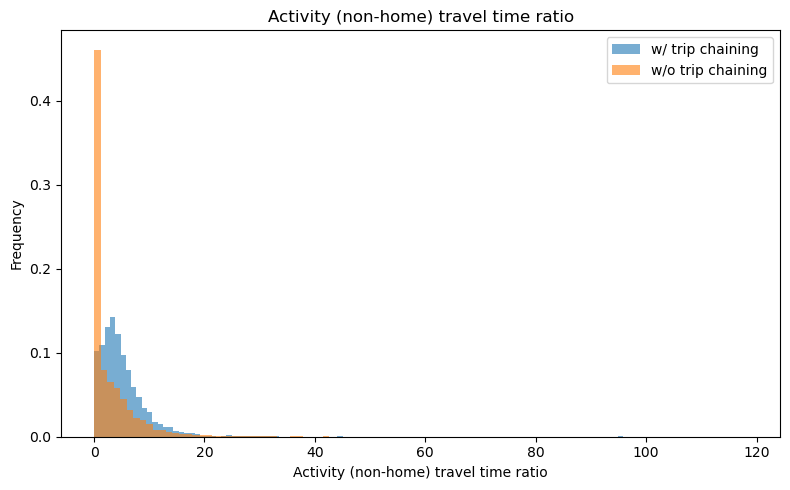

In [52]:
plt.figure(figsize=(8, 5))

plt.hist(results[results['trip_chaining_presence']==1]['activity_nh_ratio'].dropna(), bins=100, alpha=0.6, label='w/ trip chaining', density=True)
plt.hist(results[results['trip_chaining_presence']==0]['activity_nh_ratio'].dropna(), bins=100, alpha=0.6, label='w/o trip chaining', density=True)
# plt.hist(results['entropy_mm'].dropna(), bins=20, alpha=0.6, label='Third Place Entropy (Miller–Madow)')

plt.xlabel('Activity (non-home) travel time ratio')
plt.ylabel('Frequency')
plt.title('Activity (non-home) travel time ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
results.to_csv('dbs/data_p/trip_chaining_results.csv', index=False)

## 5. Travel time budget
Daily total travel time (min)

Weighted median by dow x day_type

Individually determined

In [54]:
df_day_features = df.drop_duplicates(subset=['ID', 'date'])\
    [['ID', 'date', 'weight_day', 'day_type', 'dow']].copy()

In [55]:
df_r = pd.merge(results, df_day_features, on=['ID', 'date'], how='left')
df_r.loc[:, 'weekday'] = df_r['dow'].apply(lambda x: 1 if x in ['wednesday', 'thursday', 'friday', 
                                                                'monday', 'tuesday'] 
                                           else 0)
df_r.columns

Index(['ID', 'date', 'trip_chaining_presence', 'freq_hws', 'freq_hwsx',
       'xs_total_hws', 'xs_total_hwsx', 'total_travel_time',
       'activity_time_third', 'activity_time_work_study', 'activity_time_home',
       'entropy_naive', 'entropy_mm', 'gini_simpson', 'hill_q1', 'n_visits',
       'activity_nh_ratio', 'weight_day', 'day_type', 'dow', 'weekday'],
      dtype='object')

In [56]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit two-way ANOVA with interaction
model = ols("total_travel_time ~ C(day_type)", data=df_r).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                   sum_sq       df         F    PR(>F)
C(day_type)  1.193969e+05      4.0  6.641308  0.000025
Residual     8.418611e+07  18731.0       NaN       NaN


In [57]:
df_r.groupby(['day_type', 'weekday'])[['total_travel_time', 'weight_day']].\
    apply(lambda data: helpers.weighted_median(data['total_travel_time'], data['weight_day'])).reset_index()

,day_type,weekday,0
0,Bridge day,1,53.0
1,Normal,0,65.0
2,Normal,1,83.0
3,Public holiday,0,50.0
4,Public holiday,1,89.0
5,School holiday,0,63.0
6,School holiday,1,94.0
7,Strike,1,30.0


In [58]:
df_r_id = df_r.groupby(['ID'])[['total_travel_time', 'weight_day']].\
    apply(lambda data: pd.Series(dict(total_travel_time=helpers.weighted_median(data['total_travel_time'], data['weight_day']))))\
        .reset_index()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_18812\2110188193.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


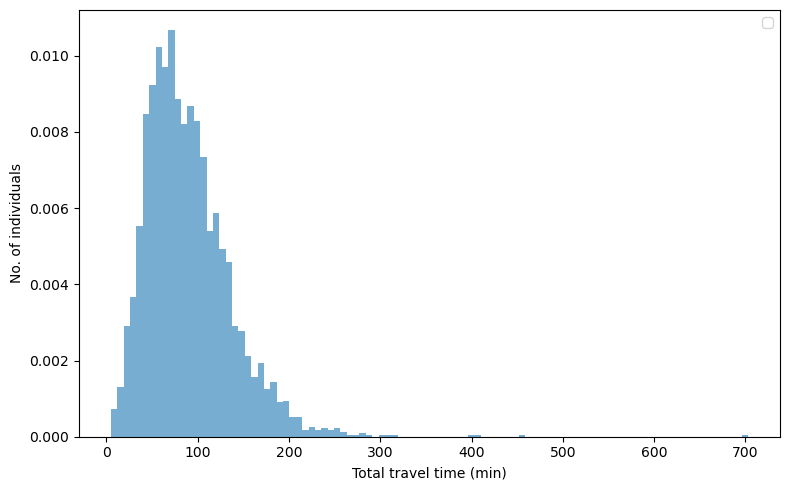

In [59]:
plt.figure(figsize=(8, 5))

plt.hist(df_r_id['total_travel_time'].dropna(), bins=100, alpha=0.6, density=True)
plt.xlabel('Total travel time (min)')
plt.ylabel('No. of individuals')
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
df_r_id['total_travel_time'].median()

np.float64(82.0)

## 6. Minimum time to carry out activities

In [61]:
df_day_features.columns, df.columns

(Index(['ID', 'date', 'weight_day', 'day_type', 'dow'], dtype='object'),
 Index(['trip_id', 'start_time', 'end_time', 'duration', 'weight_day',
        'purpose_o', 'purpose_d', 'day_type', 'dow', 'start_lat', 'start_lon',
        'end_lat', 'end_lon', 'ID', 'date', 'preceding_activity',
        'activity_duration_min'],
       dtype='object'))

In [62]:
df_act = df.groupby('purpose_o')[['activity_duration_min', 'weight_day']].\
    apply(lambda data: pd.Series(dict(activity_duration_min=helpers.\
        weighted_median(data['activity_duration_min'], data['weight_day']))))\
        .reset_index()
df_act = df_act[df_act['purpose_o'] != 'HOME']
df_act

,purpose_o,activity_duration_min
0,ACCOM,11.000000
1,BUSINESS,66.883333
2,HEALTH,44.000000
4,LEISURE,82.000000
5,OTHER,47.033333
6,PURCHASE,24.000000
7,STUDIES,251.000000
8,WORK,297.000000


In [63]:
act_time_budget = {"HEALTH": 45, "PURCHASE": 25, "LEISURE": 80}
print(act_time_budget)

{'HEALTH': 45, 'PURCHASE': 25, 'LEISURE': 80}


## 7. Workers vs. Non-workers

In [71]:
def workers_definition(data):
    CORE = {'WORK', 'STUDIES'}
    acts = data['purpose_o'].tolist() + data['purpose_d'].tolist()
    if len([x for x in acts if x == 'WORK']) > 0:
        return 1
    if len([x for x in acts if x == 'STUDIES']) > 0:
        return 2
    return 0

tqdm.pandas(desc='Defining workers')
df_workers = (
    df.drop(columns=['ID'])  # exclude the grouping column
      .groupby(df['ID'])     # group by original ID
      .progress_apply(workers_definition)
      .reset_index(name='is_worker')
)
print(f"Workers: {len(df_workers[df_workers['is_worker'] == 1])} out of {df_workers.shape[0]} individuals")

Defining workers: 100%|██████████| 3318/3318 [00:00<00:00, 14480.80it/s]

Workers: 2457 out of 3318 individuals


### 7.1 Workers' departure times
Home and work

In [72]:
workers_id = df_workers[df_workers['is_worker'] == 1]['ID'].unique()
CORE = {'WORK', 'STUDIES'}

In [74]:
df_commute = df[df['purpose_o'].isin(CORE) | df['purpose_d'].isin(CORE)].copy()
df_commute = df_commute[df_commute['ID'].isin(workers_id)].copy()

#### 7.1.1 Commuting time (t_hw)

In [75]:
df_commute['ID'].nunique()

2457

In [77]:
df_t_hw = df_commute.loc[(df_commute['purpose_o'] == 'HOME') & (df_commute['purpose_d'] == 'WORK'), ['ID', 'duration']].groupby('ID').agg({'duration': 'median'}).reset_index()

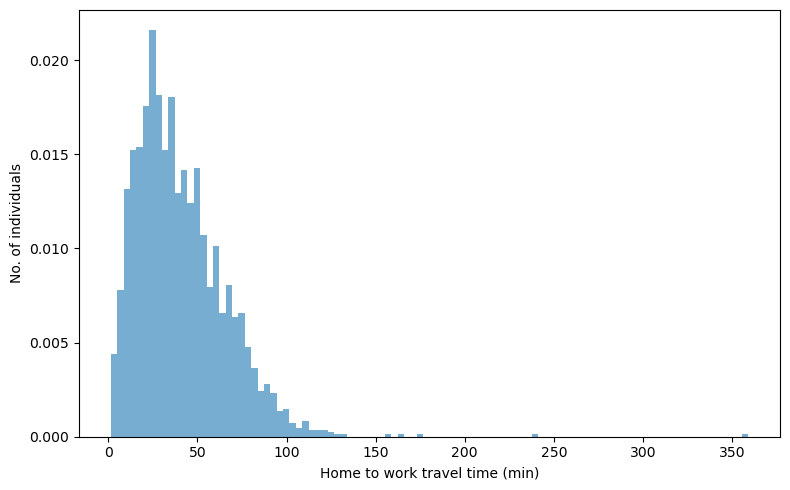

In [81]:
plt.figure(figsize=(8, 5))

plt.hist(df_t_hw['duration'].dropna(), bins=100, alpha=0.6, density=True)
plt.xlabel('Home to work travel time (min)')
plt.ylabel('No. of individuals')
plt.tight_layout()
plt.show()

#### 7.1.2 Total travel time budget (tb)

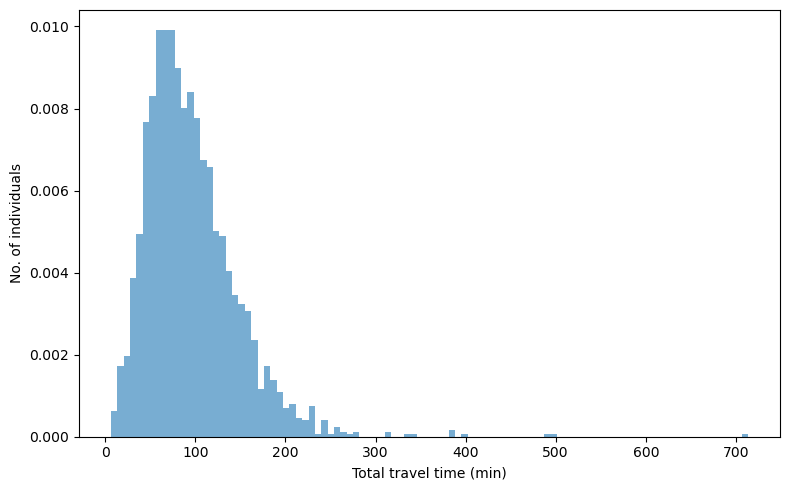

In [80]:
df_tb = df[df['dow'].isin(['monday', 'tuesday', 'wedsday', 'thursday', 'friday'])].groupby(['ID', 'date']).agg({'duration': 'sum'}).reset_index().groupby('ID').agg({'duration': 'median'}).reset_index()
df_tb = df_tb[df_tb['ID'].isin(workers_id)]
plt.figure(figsize=(8, 5))

plt.hist(df_tb['duration'].dropna(), bins=100, alpha=0.6, density=True)
plt.xlabel('Total travel time (min)')
plt.ylabel('No. of individuals')
plt.tight_layout()
plt.show()

#### 7.1.3 Departure time at work (17:30)

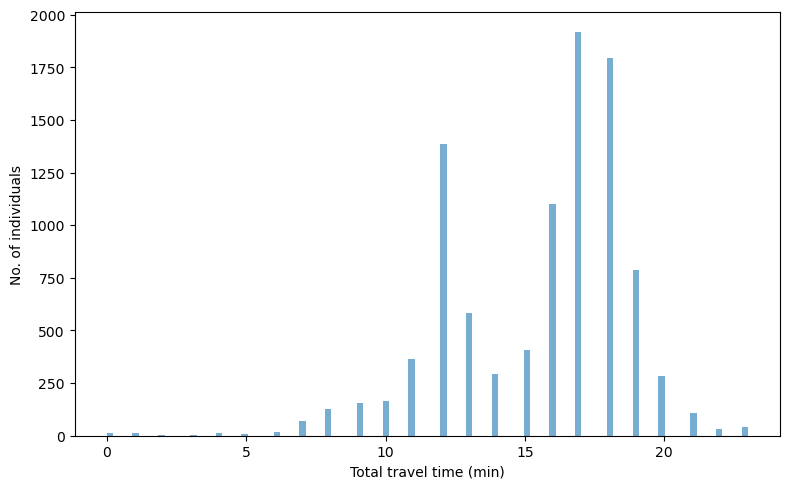

In [82]:
df_dw = df_commute[df_commute['purpose_o'] == 'WORK'].copy()
df_dw['departure_time'] = df_dw['start_time'].dt.time
df_dw['departure_time'] = df_dw['departure_time'].apply(lambda x: x.hour)  # Convert to minutes since midnight
plt.figure(figsize=(8, 5))

plt.hist(df_dw['departure_time'].dropna(), bins=100, alpha=0.6, density=False)
plt.xlabel('Total travel time (min)')
plt.ylabel('No. of individuals')
plt.tight_layout()
plt.show()

#### 7.1.4 Remaining time

In [83]:
df_time = pd.merge(df_tb.rename(columns={'duration': 'time_budget'}), df_t_hw.rename(columns={'duration': 'time_hw'}), on='ID', how='left')

In [84]:
print("Real time budget (median):", df_tb['duration'].median())
df_time.loc[:, 'tt_wkh_1'] = df_time['time_budget'] - df_time['time_hw'] * 2
print(len(df_time[df_time['tt_wkh_1'] > 0]) / len(df_time) * 100, '% of individuals have remaining time > 0')

Real time budget (median): 86.5
65.47231270358306 % of individuals have remaining time > 0


In [85]:
print(f"Assumption-based travel time budget: 90 min")
df_time.loc[:, 'tt_wkh_2'] = 90 - df_time['time_hw'] * 2
print(len(df_time[df_time['tt_wkh_2'] > 0]) / len(df_time) * 100, '% of individuals have remaining time > 0')

Assumption-based travel time budget: 90 min
58.10260586319218 % of individuals have remaining time > 0


In [56]:
df_time[['ID', 'time_budget', 'time_hw', 'tt_wkh_1', 'tt_wkh_2', 'tt_wkh_3']].to_csv('dbs/data_p/commuter_time_budget.csv', index=False)

In [57]:
df[df['ID'].isin(workers_id)].to_csv('dbs/data_p/commuter_trips.csv', index=False)